In [1]:
# Install yfinance library
!pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# Fetch historical data for Apple (AAPL)
ticker = 'AAPL'
stock_data = yf.download(ticker, start='2024-01-01', end='2026-06-01')

# Display the first few rows to verify
print("Data Shape:", stock_data.shape)
stock_data.head()

/tmp/ipykernel_12866/2062079562.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start='2024-01-01', end='2026-06-01')
[*********************100%***********************]  1 of 1 completed

Data Shape: (604, 5)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.562180,186.330843,181.831767,185.055273,82488700
2024-01-03,182.187744,183.799505,181.376915,182.158081,58414500
2024-01-04,179.873962,181.040748,178.855492,180.111267,71983600
2024-01-05,179.152115,180.714432,178.153425,179.953062,62379700
2024-01-08,183.483078,183.522639,179.468523,180.051916,59144500


In [3]:
# Drop any missing values just in case
stock_data = stock_data.dropna()

# Features (X) and Target Vector (y)
X = stock_data[['Open', 'High', 'Low', 'Volume']]
y = stock_data['Close']

# Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 483
Testing set size: 121


In [4]:
# Initialize and Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Make Predictions on the test set
y_pred = model.predict(X_test)

# Calculate Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 0.98
Root Mean Squared Error (RMSE): 1.37


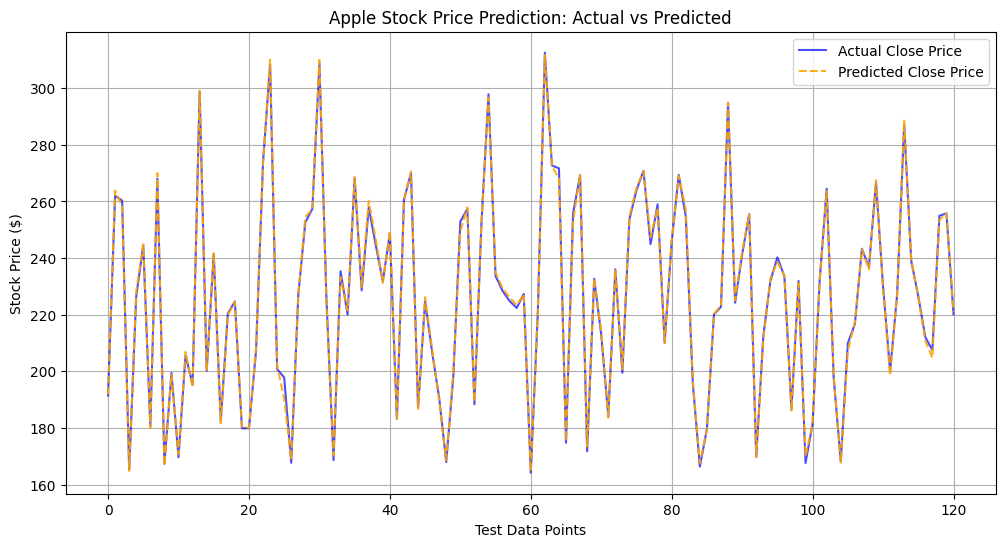

In [5]:
# Plotting the comparison
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual Close Price', color='blue', alpha=0.7)
plt.plot(y_pred, label='Predicted Close Price', color='orange', linestyle='--', alpha=0.9)
plt.title('Apple Stock Price Prediction: Actual vs Predicted')
plt.xlabel('Test Data Points')
plt.ylabel('Stock Price ($)')
plt.legend()
plt.grid(True)
plt.show()